# PROJECT BDA 420
## GROUP 14 (Lionael, Ei Htoo, James )
### Analysis on Relationship between Crime Rate and House Price

In this assignment, we will self-answer qeustions about Canadian real estate price trends and investigates how they are influenced by key socioeconomic factors.
The dataset is retrieved from github [https://github.com/tahczeban/CANADIAN_REAL_ESTATE_PRICES].

We understand that, when submitting this assingment, we are abiding to Seneca's standards of academic honesty.

In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
                    .getOrCreate()

In [0]:
from pyspark.sql.functions import avg, round, col, dense_rank, row_number, when
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

## Importing the dataset

In [0]:
dfhouse_price = spark.table("avg_house_price")
dfcrime_rate = spark.table("crime_rate")

In [0]:
dfcrime_rate.show()
dfhouse_price.show()

+----+--------+----------+
|Year|Province|Crime_rate|
+----+--------+----------+
|2015|      AB|      8917|
|2016|      AB|      9026|
|2017|      AB|      9335|
|2018|      AB|      9392|
|2019|      AB|     10027|
|2015|      BC|      8608|
|2016|      BC|      8489|
|2017|      BC|      8090|
|2018|      BC|      8251|
|2019|      BC|      9574|
|2015|      MB|      8926|
|2016|      MB|      9508|
|2017|      MB|      9758|
|2018|      MB|      9998|
|2019|      MB|     10864|
|2015|      NB|      5479|
|2016|      NB|      5276|
|2017|      NB|      5753|
|2018|      NB|      6056|
|2019|      NB|      6752|
+----+--------+----------+
only showing top 20 rows
+----+--------+---------+
|Year|Province|Avg_price|
+----+--------+---------+
|2015|      AB|   432800|
|2015|      BC|   610000|
|2015|      MB|   283000|
|2015|      NB|   199800|
|2015|      NL|   299300|
|2015|      NS|   256100|
|2015|     ONT|   455000|
|2015|     PEI|   204200|
|2015|      QC|   305800|
|2015|      SK|

In [0]:
dfcrime_rate.printSchema()

root
 |-- Year: long (nullable = true)
 |-- Province: string (nullable = true)
 |-- Crime_rate: long (nullable = true)



In [0]:
dfhouse_price.printSchema()

root
 |-- Year: long (nullable = true)
 |-- Province: string (nullable = true)
 |-- Avg_price: long (nullable = true)



## Data Cleaning and Preparation
### Removing Duplicate and Null

In [0]:
dfcrime_rate = dfcrime_rate.dropna().distinct()
print(dfcrime_rate.count())

50


In [0]:
dfhouse_price = dfhouse_price.dropna().distinct()
print(dfhouse_price.count())

70


In [0]:
# 10 Provinces from both Dataset
df_join.select(col("Province")).distinct().show()

+--------+
|Province|
+--------+
|      AB|
|      BC|
|      QC|
|      SK|
|      MB|
|      NB|
|      NS|
|     ONT|
|     PEI|
|      NL|
+--------+



- AB → Alberta
- BC → British Columbia
- QC → Quebec
- SK → Saskatchewan
- MB → Manitoba
- NB → New Brunswick
- NS → Nova Scotia
- ONT → Ontario 
- PEI → Prince Edward Island
- NL → Newfoundland and Labrador

# Transformation
## Merging or Joining 2 Datasets
###  If one side doesn’t have a match, that row disappears in an inner join.


In [0]:
df_join = dfcrime_rate.join(
    dfhouse_price,
    on=["Year", "Province"], # Join by the Year and Province columns
    how="inner"
)
df_join.show()
df_join.count()


+----+--------+----------+---------+
|Year|Province|Crime_rate|Avg_price|
+----+--------+----------+---------+
|2016|      NB|      5276|   207800|
|2018|      NL|      6042|   285000|
|2019|      NS|      5873|   282700|
|2019|     PEI|      6279|   277300|
|2017|      BC|      8090|   775400|
|2016|     ONT|      4091|   515200|
|2017|      NS|      5732|   272100|
|2018|      NS|      5686|   275700|
|2019|      BC|      9574|   785500|
|2019|      NB|      6752|   218100|
|2016|      MB|      9508|   288800|
|2018|      BC|      8251|   816300|
|2019|      QC|      4066|   359600|
|2015|      AB|      8917|   432800|
|2015|      NL|      6371|   299300|
|2015|     ONT|      4022|   455000|
|2016|      NL|      6501|   298800|
|2016|     PEI|      5013|   214700|
|2015|      MB|      8926|   283000|
|2015|      SK|     12919|   332600|
+----+--------+----------+---------+
only showing top 20 rows


50

#### Rows in house_price with NO matching (Year, Province) in crime_rate

In [0]:
df_house_no_match = dfhouse_price.join(
    dfcrime_rate,
    on=["Year", "Province"],
    how="left_anti"
)
"""
left_anti keeps only rows from the left DataFrame (dfhouse_price) 
where no matching key exists on the right (dfcrime_rate)
"""
df_house_no_match.show()
df_house_no_match.count()

+----+--------+---------+
|Year|Province|Avg_price|
+----+--------+---------+
|2020|     PEI|   312400|
|2021|      AB|   417500|
|2021|      NS|   271800|
|2021|     ONT|   863800|
|2020|      NL|   271600|
|2021|      BC|   887800|
|2020|      NS|   305000|
|2021|      MB|   318100|
|2020|      BC|   848200|
|2020|      MB|   314400|
|2021|      NL|   289000|
|2021|      SK|   274000|
|2020|      QC|   396100|
|2021|     PEI|   260600|
|2021|      QC|   421400|
|2020|     ONT|   705000|
|2020|      SK|   323700|
|2020|      AB|   420900|
|2020|      NB|   222700|
|2021|      NB|   217100|
+----+--------+---------+



20

## Filtering


In [0]:
"""
Filtering the dataset between 2015 and 2019 and order by Province
"""
df_join.filter((col('Year') >= 2015) & (col('Year') <= 2019)).orderBy("Province").show()

+----+--------+----------+---------+
|Year|Province|Crime_rate|Avg_price|
+----+--------+----------+---------+
|2018|      AB|      9392|   428500|
|2017|      AB|      9335|   429800|
|2016|      AB|      9026|   425900|
|2019|      AB|     10027|   420900|
|2015|      AB|      8917|   432800|
|2018|      BC|      8251|   816300|
|2015|      BC|      8608|   610000|
|2016|      BC|      8489|   717600|
|2019|      BC|      9574|   785500|
|2017|      BC|      8090|   775400|
|2019|      MB|     10864|   305200|
|2018|      MB|      9998|   300000|
|2017|      MB|      9758|   297400|
|2016|      MB|      9508|   288800|
|2015|      MB|      8926|   283000|
|2016|      NB|      5276|   207800|
|2018|      NB|      6056|   214800|
|2015|      NB|      5479|   199800|
|2019|      NB|      6752|   218100|
|2017|      NB|      5753|   208200|
+----+--------+----------+---------+
only showing top 20 rows


In [0]:
"""
Showing the lowest crime rate
"""
df_join.orderBy(col("Crime_rate").asc()).show(10)

+----+--------+----------+---------+
|Year|Province|Crime_rate|Avg_price|
+----+--------+----------+---------+
|2015|     ONT|      4022|   455000|
|2019|      QC|      4066|   359600|
|2016|     ONT|      4091|   515200|
|2018|      QC|      4165|   341000|
|2016|      QC|      4233|   316000|
|2015|      QC|      4252|   305800|
|2017|     ONT|      4259|   600300|
|2017|      QC|      4330|   327900|
|2018|     ONT|      4509|   606600|
|2019|     ONT|      4544|   630600|
+----+--------+----------+---------+
only showing top 10 rows


In [0]:
"""
Showing the lowest house price
"""
df_join.orderBy(col("Avg_price").asc()).show(10)

+----+--------+----------+---------+
|Year|Province|Crime_rate|Avg_price|
+----+--------+----------+---------+
|2015|      NB|      5479|   199800|
|2015|     PEI|      4750|   204200|
|2016|      NB|      5276|   207800|
|2017|      NB|      5753|   208200|
|2016|     PEI|      5013|   214700|
|2018|      NB|      6056|   214800|
|2019|      NB|      6752|   218100|
|2017|     PEI|      4713|   240400|
|2015|      NS|      5727|   256100|
|2016|      NS|      5590|   261800|
+----+--------+----------+---------+
only showing top 10 rows


## Grouping and Aggregating

In [0]:

"""
Grouping the dataset by province and aggregating the crime rate and house price
"""
df_province = df_join.groupBy("Province").agg(
                 avg("Crime_rate").alias("avg_crime_rate"),
                 avg("Avg_price").alias("avg_house_price")
             ).orderBy("Province")
df_province.show()

+--------+--------------+---------------+
|Province|avg_crime_rate|avg_house_price|
+--------+--------------+---------------+
|      AB|        9339.4|       427580.0|
|      BC|        8602.4|       740960.0|
|      MB|        9810.8|       294880.0|
|      NB|        5863.2|       209740.0|
|      NL|        6328.6|       290140.0|
|      NS|        5721.6|       269680.0|
|     ONT|        4285.0|       561540.0|
|     PEI|        5229.4|       240600.0|
|      QC|        4209.2|       330060.0|
|      SK|       12995.2|       328660.0|
+--------+--------------+---------------+



In [0]:
"""
Grouping the dataset by year and aggregating the crime rate and house price
"""
df_aggregate = df_join.groupBy("Year").agg(
                 avg("Crime_rate").alias("avg_crime_rate"),
                 avg("Avg_price").alias("avg_house_price")
             ).orderBy("Year")
df_aggregate.show()

+----+--------------+---------------+
|Year|avg_crime_rate|avg_house_price|
+----+--------------+---------------+
|2015|        6997.1|       337860.0|
|2016|        7123.8|       357930.0|
|2017|        7099.5|       377630.0|
|2018|        7215.6|       386070.0|
|2019|        7756.4|       387430.0|
+----+--------------+---------------+



## Window operations

Window functions let us look at each province’s crime and house prices over time, compute moving averages, and rank years within each province, without losing row‑level detail like we would with a simple groupBy.

In [0]:
"""
Moving average over time for each province.
"""
windowSpec = (
    Window
    .partitionBy("Province")
    .orderBy(col("Year"))
    .rowsBetween(-1, 1) # 1 year before, current, 1 year after (3 years window)
)
"""
Calculating the moving average of Crime Rate and Average House Price (3 years window) for each province
"""
df_window = df_join.withColumn(
    "Crime_rate_mean_window",
    round(avg(col("Crime_rate")).over(windowSpec),2)
)

df_window = df_window.withColumn(
    "Avg_price_mean_window",
    round(avg(col("Avg_price")).over(windowSpec),2)
)
df_window.show(50)


+----+--------+----------+---------+----------------------+---------------------+
|Year|Province|Crime_rate|Avg_price|Crime_rate_mean_window|Avg_price_mean_window|
+----+--------+----------+---------+----------------------+---------------------+
|2015|      AB|      8917|   432800|                8971.5|             429350.0|
|2016|      AB|      9026|   425900|               9092.67|             429500.0|
|2017|      AB|      9335|   429800|                9251.0|            428066.67|
|2018|      AB|      9392|   428500|               9584.67|             426400.0|
|2019|      AB|     10027|   420900|                9709.5|             424700.0|
|2015|      BC|      8608|   610000|                8548.5|             663800.0|
|2016|      BC|      8489|   717600|               8395.67|             701000.0|
|2017|      BC|      8090|   775400|               8276.67|            769766.67|
|2018|      BC|      8251|   816300|               8638.33|             792400.0|
|2019|      BC| 

In [0]:
"""
Ranking the crime rate for each province
"""
window_high_crime = Window.partitionBy("Province").orderBy(col("Crime_rate").desc())
window_low_crime = Window.partitionBy("Province").orderBy(col("Crime_rate").asc())

df_ranked = (
    df_join
    .withColumn("row_number_high_crime", row_number().over(window_hot_crime))
    .withColumn("rank_low_crime_rate", dense_rank().over(window_cold_crime))
)

df_ranked.show()  

+----+--------+----------+---------+---------------------+-------------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|
+----+--------+----------+---------+---------------------+-------------------+
|2015|      AB|      8917|   432800|                    5|                  1|
|2016|      AB|      9026|   425900|                    4|                  2|
|2017|      AB|      9335|   429800|                    3|                  3|
|2018|      AB|      9392|   428500|                    2|                  4|
|2019|      AB|     10027|   420900|                    1|                  5|
|2017|      BC|      8090|   775400|                    5|                  1|
|2018|      BC|      8251|   816300|                    4|                  2|
|2016|      BC|      8489|   717600|                    3|                  3|
|2015|      BC|      8608|   610000|                    2|                  4|
|2019|      BC|      9574|   785500|                

In [0]:
"""
Ranking the house price for each province
"""
window_high_price = Window.partitionBy("Province").orderBy(col("Avg_price").desc())
window_low_price  = Window.partitionBy("Province").orderBy(col("Avg_price").asc())

df_ranked_price = (
    df_ranked
    .withColumn("row_number_high_price", row_number().over(window_high_price))
    .withColumn("rank_low_price", dense_rank().over(window_low_price))
)

df_ranked_price.show()


+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|row_number_high_price|rank_low_price|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|2019|      AB|     10027|   420900|                    1|                  5|                    5|             1|
|2016|      AB|      9026|   425900|                    4|                  2|                    4|             2|
|2018|      AB|      9392|   428500|                    2|                  4|                    3|             3|
|2017|      AB|      9335|   429800|                    3|                  3|                    2|             4|
|2015|      AB|      8917|   432800|                    5|                  1|                    1|             5|
|2015|      BC|      8608|   610000|                    2|              

In [0]:
"""
Finding the best places and time to live
"""
df_ranked_price.filter(
    (col("rank_low_crime_rate") == 1) &
    (col("rank_low_price") == 1)
).show()


+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|row_number_high_price|rank_low_price|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|2015|      MB|      8926|   283000|                    5|                  1|                    5|             1|
|2015|     ONT|      4022|   455000|                    5|                  1|                    5|             1|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+



In [0]:
"""
Finding the worst places and time to live
"""
df_ranked_price.filter(
    (col("rank_low_crime_rate") == 5) &
    (col("rank_low_price") == 5)
).show()

+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|row_number_high_price|rank_low_price|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|2019|      MB|     10864|   305200|                    1|                  5|                    1|             5|
|2019|      NB|      6752|   218100|                    1|                  5|                    1|             5|
|2019|      NS|      5873|   282700|                    1|                  5|                    1|             5|
|2019|     ONT|      4544|   630600|                    1|                  5|                    1|             5|
|2019|     PEI|      6279|   277300|                    1|                  5|                    1|             5|
|2016|      SK|     13511|   332700|                    1|              

## When / Otherwise

In [0]:
"""
Categorizing the crime rate and house price into High, Medium and Low levels
"""
df_cat = df_join.withColumn(
    "Crime_level",
    when(col("Crime_rate") >= 8000, "HIGH")
     .when(col("Crime_rate") >= 6500, "MEDIUM")
     .otherwise("LOW"))

df_cat = df_cat.withColumn(
    "Price_level",
    when(col("Avg_price") >= 380000, "HIGH")
     .when(col("Avg_price") >= 350000, "MEDIUM")
     .otherwise("LOW")
)
df_cat.show(50)

+----+--------+----------+---------+-----------+-----------+
|Year|Province|Crime_rate|Avg_price|Crime_level|Price_level|
+----+--------+----------+---------+-----------+-----------+
|2016|      NB|      5276|   207800|        LOW|        LOW|
|2018|      NL|      6042|   285000|        LOW|        LOW|
|2019|      NS|      5873|   282700|        LOW|        LOW|
|2019|     PEI|      6279|   277300|        LOW|        LOW|
|2017|      BC|      8090|   775400|       HIGH|       HIGH|
|2016|     ONT|      4091|   515200|        LOW|       HIGH|
|2017|      NS|      5732|   272100|        LOW|        LOW|
|2018|      NS|      5686|   275700|        LOW|        LOW|
|2019|      BC|      9574|   785500|       HIGH|       HIGH|
|2019|      NB|      6752|   218100|     MEDIUM|        LOW|
|2016|      MB|      9508|   288800|       HIGH|        LOW|
|2018|      BC|      8251|   816300|       HIGH|       HIGH|
|2019|      QC|      4066|   359600|        LOW|     MEDIUM|
|2015|      AB|      891

In [0]:
"""
Making a recommendation based on the rank_low_crime_rate and rank_low_price columns
"""
df_recommend = df_ranked_price.withColumn(
    "recommend",
    when(
        (col("rank_low_crime_rate") <= 2) & (col("rank_low_price") <= 2),
        "YES"
    ).otherwise("NO")
)
df_recommend.select("Year","Province","Avg_price","rank_low_crime_rate","rank_low_price","recommend").show(50)

+----+--------+---------+-------------------+--------------+---------+
|Year|Province|Avg_price|rank_low_crime_rate|rank_low_price|recommend|
+----+--------+---------+-------------------+--------------+---------+
|2019|      AB|   420900|                  5|             1|       NO|
|2016|      AB|   425900|                  2|             2|      YES|
|2018|      AB|   428500|                  4|             3|       NO|
|2017|      AB|   429800|                  3|             4|       NO|
|2015|      AB|   432800|                  1|             5|       NO|
|2015|      BC|   610000|                  4|             1|       NO|
|2016|      BC|   717600|                  3|             2|       NO|
|2017|      BC|   775400|                  1|             3|       NO|
|2019|      BC|   785500|                  5|             4|       NO|
|2018|      BC|   816300|                  2|             5|       NO|
|2015|      MB|   283000|                  1|             1|      YES|
|2016|

## Visualization

### Distribution of Crime Rate

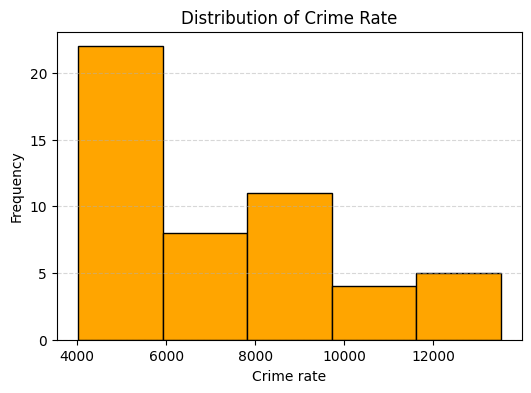

In [0]:
pdf_all = df_ranked_price.toPandas()

plt.figure(figsize=(6, 4))
plt.hist(pdf_all["Crime_rate"], bins=5, color="orange", edgecolor="black")
plt.title("Distribution of Crime Rate")
plt.xlabel("Crime rate")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


Overall, the distribution is skewed towards lower crime rates, with only a handful of very high‑crime observations

### Distribution of Average House Price

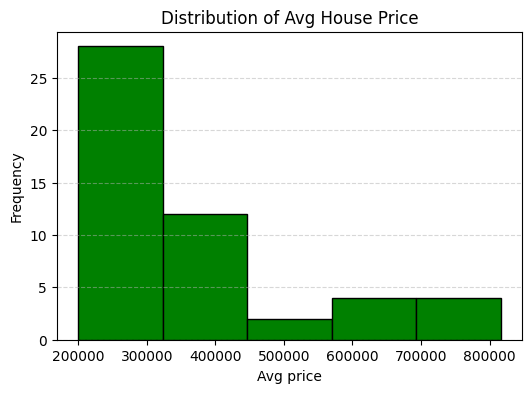

In [0]:
plt.figure(figsize=(6, 4))
plt.hist(pdf_all["Avg_price"], bins=5, color="green", edgecolor="black")
plt.title("Distribution of Avg House Price")
plt.xlabel("Avg price")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


The distribution is skewed towards lower average house price

### Line Chart of Average Crime Rate by Year

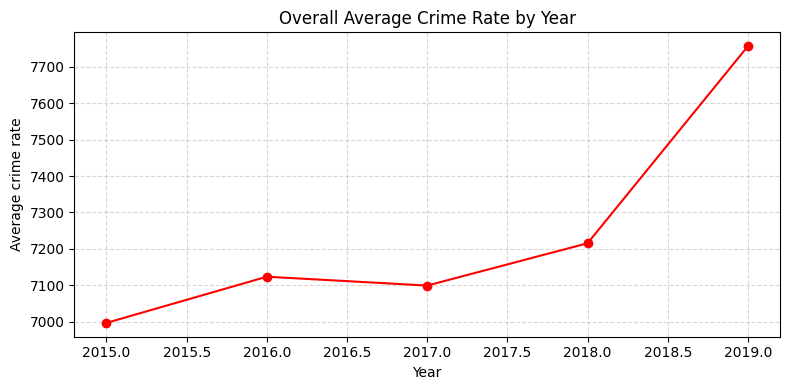

In [0]:
plt.figure(figsize=(8, 4))
plt.plot(
    pdf_agg["Year"],
    pdf_agg["avg_crime_rate"],
    marker="o",
    linestyle="-",
    color="red"
)
plt.title("Average Crime Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average crime rate")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


From 2015 to 2019, the overall average crime rate shows a mild upward trend at first, followed by a sharp spike in 2019. After a small dip in 2017, crime begins to rise again, culminating in the highest level of the period in 2019.

### Line Chart of Average House Price By Year

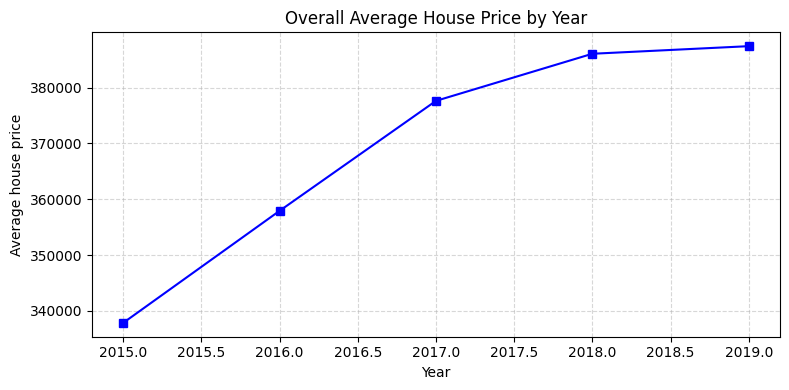

In [0]:
plt.figure(figsize=(8, 4))
plt.plot(
    pdf_agg["Year"],
    pdf_agg["avg_house_price"],
    marker="s",
    linestyle="-",
    color="blue"
)
plt.title("Overall Average House Price by Year")
plt.xlabel("Year")
plt.ylabel("Average house price")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Between 2015 and 2019, average house prices increased consistently each year. The fastest growth occurs between 2015 and 2017, after which the rate of increase slows, but prices continue to reach new highs by 2019

### Bar Chart Average Crime Rate by Province

In [0]:
df_province.orderBy(col("avg_crime_rate").desc()).show()

+--------+--------------+---------------+
|Province|avg_crime_rate|avg_house_price|
+--------+--------------+---------------+
|      SK|       12995.2|       328660.0|
|      MB|        9810.8|       294880.0|
|      AB|        9339.4|       427580.0|
|      BC|        8602.4|       740960.0|
|      NL|        6328.6|       290140.0|
|      NB|        5863.2|       209740.0|
|      NS|        5721.6|       269680.0|
|     PEI|        5229.4|       240600.0|
|     ONT|        4285.0|       561540.0|
|      QC|        4209.2|       330060.0|
+--------+--------------+---------------+



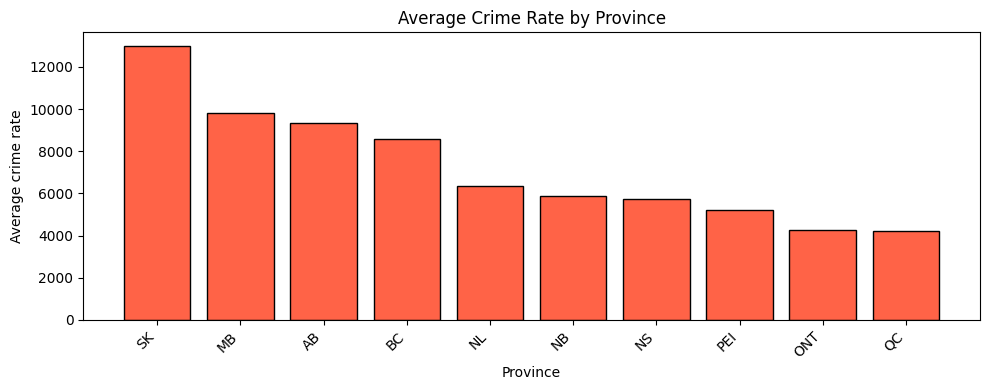

In [0]:
pdf_by_prov = df_province.toPandas()
pdf_by_prov_1 = pdf_by_prov.sort_values("avg_crime_rate", ascending=False)



plt.figure(figsize=(10, 4))
plt.bar(
    pdf_by_prov_1["Province"],
    pdf_by_prov_1["avg_crime_rate"],
    color="tomato",
    edgecolor="black"
)

plt.title("Average Crime Rate by Province")
plt.xlabel("Province")
plt.ylabel("Average crime rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



From 2015 to 2019, both average crime rates and house prices steadily increased over time, and across provinces the average crime rate is highest in Saskatchewan and then gradually decreases toward Quebec and Ontario.

### Bar Chart of Average House Price by Province

In [0]:
df_province.orderBy(col("avg_house_price").desc()).show()

+--------+--------------+---------------+
|Province|avg_crime_rate|avg_house_price|
+--------+--------------+---------------+
|      BC|        8602.4|       740960.0|
|     ONT|        4285.0|       561540.0|
|      AB|        9339.4|       427580.0|
|      QC|        4209.2|       330060.0|
|      SK|       12995.2|       328660.0|
|      MB|        9810.8|       294880.0|
|      NL|        6328.6|       290140.0|
|      NS|        5721.6|       269680.0|
|     PEI|        5229.4|       240600.0|
|      NB|        5863.2|       209740.0|
+--------+--------------+---------------+



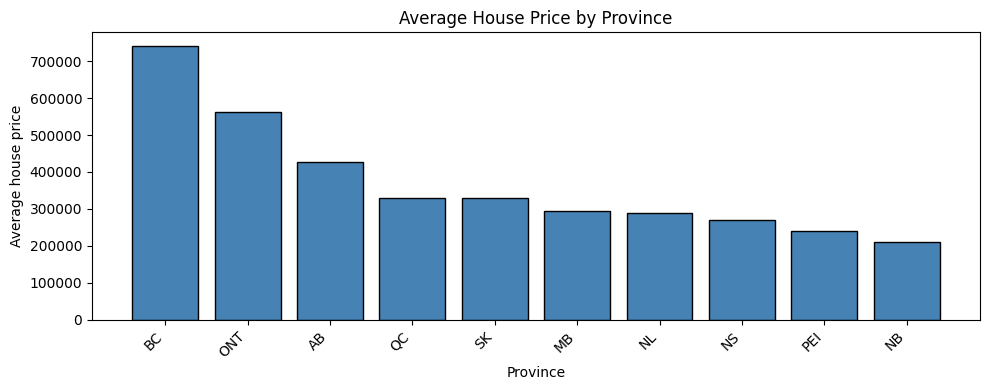

In [0]:
pdf_by_prov_2 = pdf_by_prov.sort_values("avg_house_price", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(
    pdf_by_prov_2["Province"],
    pdf_by_prov_2["avg_house_price"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Average House Price by Province")
plt.xlabel("Province")
plt.ylabel("Average house price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


BC and Ontario have the highest average house prices, and then prices drop steadily across the other provinces, with New Brunswick having the lowest.